# **Hotel Chain-A Predicitive Analysis: GROUP B14**


---



---





In [ ]:
#Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             roc_curve, precision_recall_curve,
                             average_precision_score)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Loading the datasets
train= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataScience Project Lifecycle/Hotel-A-train.csv')
validation= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataScience Project Lifecycle/Hotel-A-validation.csv')
test= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataScience Project Lifecycle/Hotel-A-test.csv')

print(f"Train:      {train.shape}")
print(f"Validation: {validation.shape}")
print(f"Test:       {test.shape}")

Train:      (27499, 24)
Validation: (2749, 24)
Test:       (4318, 23)


## **Summary Statistics**




In [ ]:
#Descriptive summary
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27499 entries, 0 to 27498
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          27499 non-null  int64 
 1   Gender                  27499 non-null  object
 2   Age                     27499 non-null  int64 
 3   Ethnicity               27499 non-null  object
 4   Educational_Level       27499 non-null  object
 5   Income                  27499 non-null  object
 6   Country_region          27499 non-null  object
 7   Hotel_Type              27499 non-null  object
 8   Expected_checkin        27499 non-null  object
 9   Expected_checkout       27499 non-null  object
 10  Booking_date            27499 non-null  object
 11  Adults                  27499 non-null  int64 
 12  Children                27499 non-null  int64 
 13  Babies                  27499 non-null  int64 
 14  Meal_Type               27499 non-null  object
 15  Vi

In [ ]:
#Numerical
num_cols = ['Age', 'Adults', 'Children', 'Babies', 'Discount_Rate', 'Room_Rate']

num_stats = train[num_cols].describe().T
num_stats = num_stats[['min', 'max', 'mean', 'std', '25%', '50%', '75%']]
num_stats.columns = ['Min', 'Max', 'Mean', 'Std', 'Q1', 'Median', 'Q3']
num_stats = num_stats.round(2)

display(num_stats)

,Min,Max,Mean,Std,Q1,Median,Q3
Age,18.0,70.0,43.98,15.30,31.0,44.0,57.0
Adults,1.0,5.0,2.33,1.18,2.0,2.0,3.0
Children,1.0,3.0,1.74,0.72,1.0,2.0,2.0
Babies,0.0,2.0,0.35,0.57,0.0,0.0,1.0
Discount_Rate,0.0,40.0,12.50,11.21,5.0,10.0,20.0
Room_Rate,100.0,250.0,175.14,43.88,137.0,175.0,214.0


In [ ]:
#Categorical
cat_cols = ['Gender', 'Ethnicity', 'Educational_Level', 'Income',
            'Country_region', 'Hotel_Type', 'Meal_Type', 'Visted_Previously',
            'Previous_Cancellations', 'Deposit_type', 'Booking_channel',
            'Required_Car_Parking', 'Reservation_Status', 'Use_Promotion']
cat_summary = pd.DataFrame([{
    'Feature':        col,
    'Unique Values':  train[col].nunique(),
    'Most Frequent':  train[col].value_counts().index[0],
    'Freq Count':     train[col].value_counts().iloc[0],
    'Value Counts':   dict(train[col].value_counts())
}for col in cat_cols])

display(cat_summary)

,Feature,Unique Values,Most Frequent,Freq Count,Value Counts
0,Gender,2,F,13799,"{'F': 13799, 'M': 13700}"
1,Ethnicity,4,African American,6965,"{'African American': 6965, 'caucasian': 6890, ..."
2,Educational_Level,4,College,11052,"{'College': 11052, 'High-School': 5522, 'Mid-S..."
3,Income,4,50K -- 100K,7936,"{'50K -- 100K': 7936, '25K --50K': 7870, '<25K..."
4,Country_region,4,South,10917,"{'South': 10917, 'North': 5670, 'East': 5460, ..."
5,Hotel_Type,3,Airport Hotels,9258,"{'Airport Hotels': 9258, 'City Hotel': 9134, '..."
6,Meal_Type,3,BB,14224,"{'BB': 14224, 'HB': 8081, 'FB': 5194}"
7,Visted_Previously,2,No,18344,"{'No': 18344, 'Yes': 9155}"
8,Previous_Cancellations,2,No,24379,"{'No': 24379, 'Yes': 3120}"
9,Deposit_type,3,No Deposit,18244,"{'No Deposit': 18244, 'Refundable': 6984, 'Non..."


## **Data Quality**

In [ ]:
#Missing values
print("Missing values:")
print(train.isnull().sum()[train.isnull().sum() > 0].to_string() or "None")

Missing values:
Series([], )


In [ ]:
#Duplicates
print(f"\nDuplicate rows: {train.duplicated().sum()}")

#Negative values in numerical columns
print("\nNegative value counts:")
for col in num_cols:
    neg = (train[col] < 0).sum()
    if neg > 0:
        print(f"  {col}: {neg}")


Duplicate rows: 0

Negative value counts:


In [ ]:
#Date parsing

#Converting strings to datetime objects is essential for 'Systems Thinking'.

for df in [train, validation, test]:
    for dcol in ['Expected_checkin', 'Expected_checkout', 'Booking_date']:
        df[dcol] = pd.to_datetime(df[dcol], errors='coerce')

unparseable = {dcol: train[dcol].isna().sum()
               for dcol in ['Expected_checkin', 'Expected_checkout', 'Booking_date']}
print(f"\nUnparseable dates: {unparseable}")


Unparseable dates: {'Expected_checkin': np.int64(0), 'Expected_checkout': np.int64(0), 'Booking_date': np.int64(0)}


In [ ]:
#Inconsistent status labels
print(f"\nReservation_Status unique values: {sorted(train['Reservation_Status'].unique())}")


Reservation_Status unique values: ['Canceled', 'Check-Out', 'Check-out', 'No-Show']


In [ ]:
#Negative lead time (booking date after check-in date)

#Calculating 'Negative Lead Time' identifies data entry errors where a booking date appears to be after the check-in date.

lead_check = (train['Expected_checkin'] - train['Booking_date']).dt.days
print(f"Negative lead time records: {(lead_check < 0).sum()}")

Negative lead time records: 506


In [ ]:
#Class imbalance
canceled = train['Reservation_Status'].isin(['Canceled']).sum()
print(f"\nCancellation rate: {canceled}/{len(train)} = {round(canceled/len(train)*100,1)}%")


Cancellation rate: 4134/27499 = 15.0%


## **Exploratory Data Analaysis (EDA) before feature engineering**

In [ ]:
sns.set_theme(style='whitegrid', palette='muted')

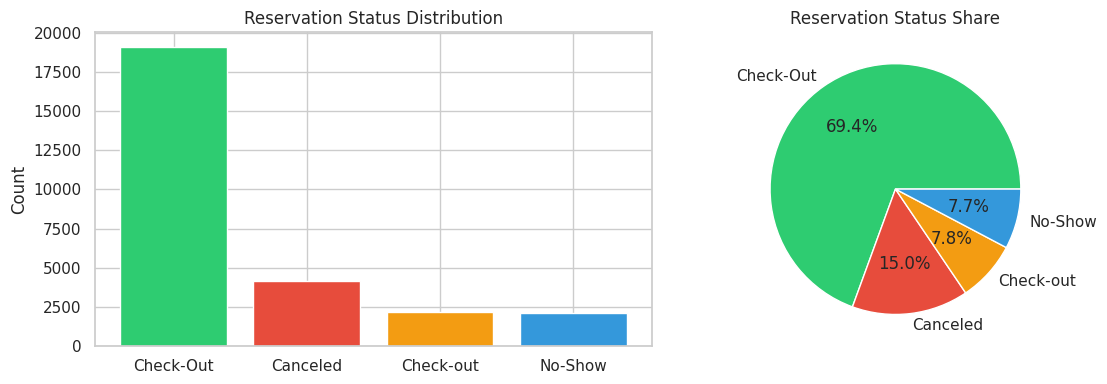

In [ ]:
#Visualization 1 — Status distribution

#This dual-plot identifies the baseline cancellation rate (15%).
#Understanding the ratio of 'Check-Out' vs 'Canceled' allows Hotel Chain A to calculate the "perishability risk" of their inventory.
#A 15% loss rate is significant enough to justify a predictive modeling intervention.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
status = train['Reservation_Status'].value_counts()
axes[0].bar(status.index, status.values, color=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'])
axes[0].set_title('Reservation Status Distribution')
axes[0].set_ylabel('Count')
axes[1].pie(status.values, labels=status.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'])
axes[1].set_title('Reservation Status Share')
plt.tight_layout()
plt.show()

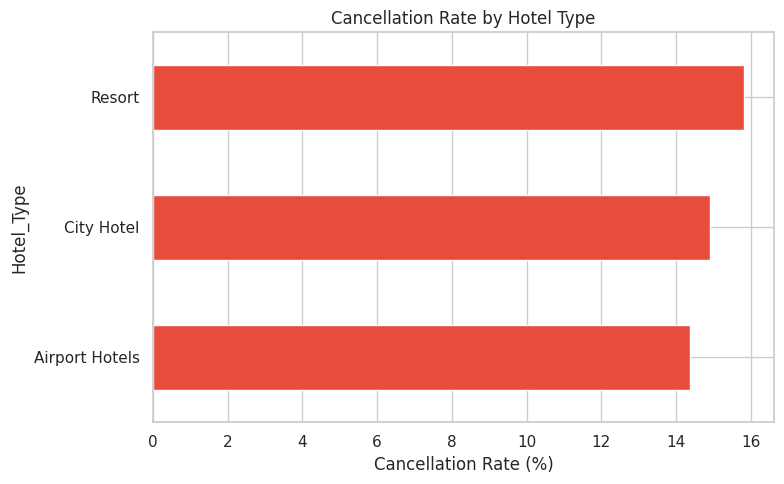

In [ ]:
#Visualization 2 — Cancellation rate by hotel type

#This chart compares Resort, City, and Airport hotels.
#It identifies which hotel vertical is most volatile.
#If Airport hotels have higher rates, it suggests transit-related cancellations, requiring different overbooking strategies than leisure-focused Resort hotels.

fig, ax = plt.subplots(figsize=(8, 5))
cr_hotel = (train.groupby('Hotel_Type')['Reservation_Status']
            .apply(lambda x: x.isin(['Canceled']).mean() * 100))
cr_hotel.sort_values().plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_xlabel('Cancellation Rate (%)')
ax.set_title('Cancellation Rate by Hotel Type')
plt.tight_layout()
plt.show()

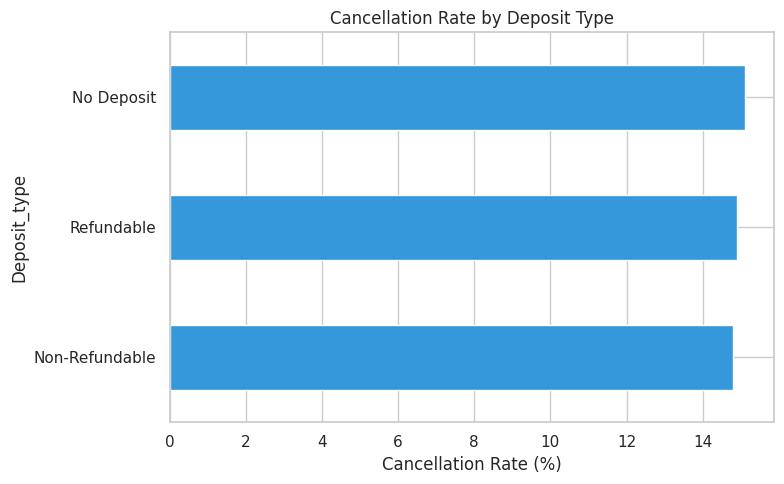

In [ ]:
#Visualization 3 — Cancellation rate by deposit type

#This is an important  driver. It visualizes how "No Deposit" bookings correlate with higher cancellation volumes compared to "Non-Refundable" ones.
#Directly supports the recommendation for a tiered deposit policy to "lock in" guest commitment.

fig, ax = plt.subplots(figsize=(8, 5))
cr_deposit = (train.groupby('Deposit_type')['Reservation_Status']
              .apply(lambda x: x.isin(['Canceled']).mean() * 100))
cr_deposit.sort_values().plot(kind='barh', ax=ax, color='#3498db')
ax.set_xlabel('Cancellation Rate (%)')
ax.set_title('Cancellation Rate by Deposit Type')
plt.tight_layout()
plt.show()

## **Feature Engineering**

In [ ]:
#Feature Engineering Function

#Transforming raw data into 'Signal'.
#Lead_Time: Captures the 'Commitment Window'.
#Stay_Duration: Estimates the total revenue at risk.
#heckin_Month: Captures seasonal tourism trends in Sri Lanka.
#Total_Guests: Distinguishes between solo business travelers and high-value families.

def engineer_features(df):
    df = df.copy()     # Uses df.copy() so the original dataframe is never mutated.
    for dcol in ['Expected_checkin', 'Expected_checkout', 'Booking_date']:
        df[dcol] = pd.to_datetime(df[dcol], errors='coerce')

    # Days between booking and check-in — strongest cancellation signal
    df['Lead_Time']         = (df['Expected_checkin'] - df['Booking_date']).dt.days

    # Number of nights booked
    df['Stay_Duration']     = (df['Expected_checkout'] - df['Expected_checkin']).dt.days

    # Arrival month and weekday — seasonality and business/leisure split
    df['Checkin_Month']     = df['Expected_checkin'].dt.month
    df['Checkin_DayOfWeek'] = df['Expected_checkin'].dt.dayofweek

    # Total party size
    df['Total_Guests']      = df['Adults'] + df['Children'] + df['Babies']

    return df

In [ ]:
train = engineer_features(train)
validation   = engineer_features(validation)
test  = engineer_features(test)

## **Fixing Outliers**

In [ ]:
#Interquartile Range (IQR) Clipping

#Capping extreme values in 'Room_Rate' and 'Stay_Duration'.
#This prevents the model from being skewed, ensuring the Random Forest generalizes well to average guests.
#Bounds computed from train only — applied to all splits to avoid leakage

for col in ['Lead_Time', 'Stay_Duration', 'Room_Rate']:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    for df in [train, validation, test]:
        df[col] = df[col].clip(lower, upper)

## **Exploratory Data after feature engineering**

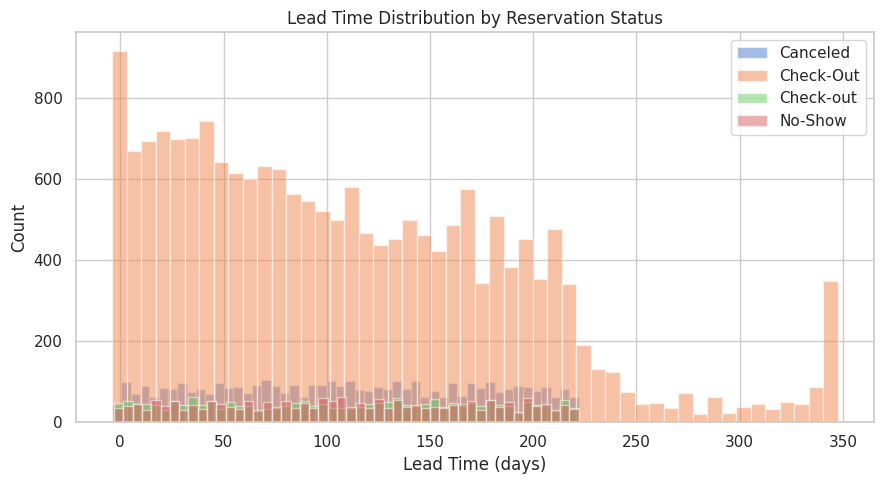

In [ ]:
#Visualization 4 — Lead time distribution by status

#Shows a clear trend—as the gap between booking and check-in (Lead Time) increases, the probability of cancellation rises.
#This confirms 'Commitment Decay.' The hotel should focus its re-confirmation efforts on guests who booked more than 30 days in advance.

fig, ax = plt.subplots(figsize=(9, 5))
for label, grp in train.groupby('Reservation_Status'):
    ax.hist(grp['Lead_Time'].dropna(), bins=50, alpha=0.5, label=label)
ax.set_xlabel('Lead Time (days)')
ax.set_ylabel('Count')
ax.set_title('Lead Time Distribution by Reservation Status')
ax.legend()
plt.tight_layout()
plt.show()

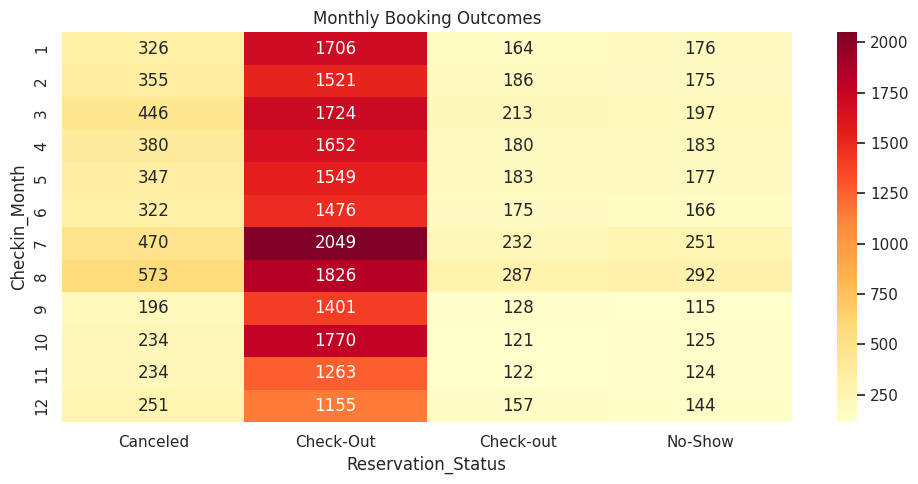

In [ ]:
#Visualization 5 — Monthly booking outcomes heatmap

#Identifies seasonal spikes in cancellations.
#Helps management plan for "High-Risk Seasons." For example, if December shows high cancellations, the hotel can aggressively overbook during that month to ensure 100% occupancy.

pivot = train.groupby(['Checkin_Month', 'Reservation_Status']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Monthly Booking Outcomes')
plt.tight_layout()
plt.show()

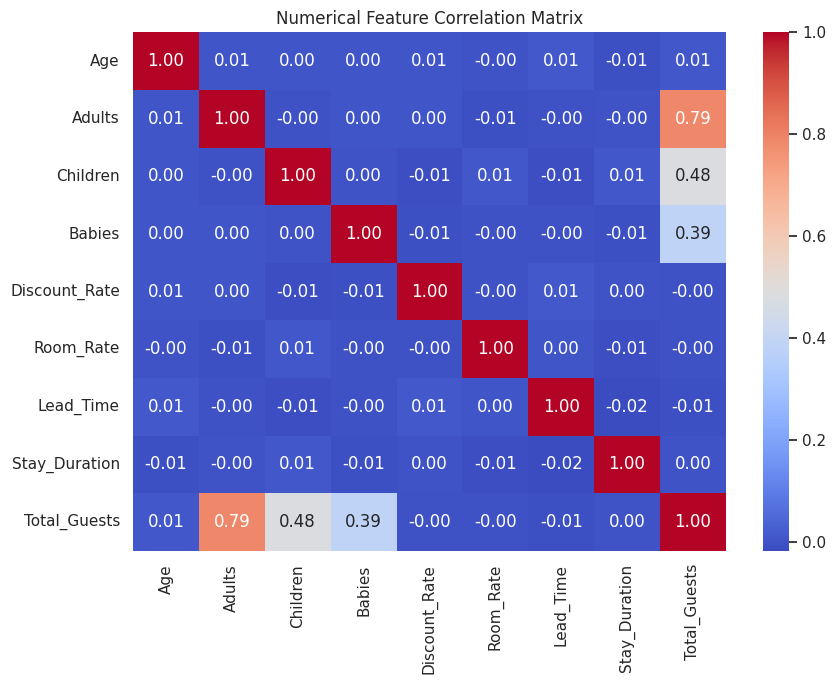

In [ ]:
#Visualization 6 — Numerical correlation matrix

#Measures the strength of the linear relationship between variables.
#We look for high correlation between 'Lead_Time' and 'Reservation_Status'.
#This ensures we aren't using "redundant" features

num_for_corr = ['Age', 'Adults', 'Children', 'Babies', 'Discount_Rate',
                'Room_Rate', 'Lead_Time', 'Stay_Duration', 'Total_Guests']
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(train[num_for_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Numerical Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## **Label Encoding**

In [ ]:
#Fit each encoder on TRAIN, then apply to validation and test.
#Fitting separately per split is causes category code mistmatch
#This prevents 'Data Leakage' and ensures the model doesn't crash during real-world deployment when it encounters a new country or ethnicity.

FEATURES = [
    'Age', 'Adults', 'Children', 'Babies', 'Discount_Rate', 'Room_Rate',
    'Lead_Time', 'Stay_Duration', 'Total_Guests', 'Checkin_Month', 'Checkin_DayOfWeek',
    'Gender', 'Ethnicity', 'Educational_Level', 'Income', 'Country_region',
    'Hotel_Type', 'Meal_Type', 'Visted_Previously', 'Previous_Cancellations',
    'Deposit_type', 'Booking_channel', 'Required_Car_Parking', 'Use_Promotion'
]

CAT = [c for c in FEATURES
                    if pd.api.types.is_string_dtype(train[c]) or train[c].dtype == object]

encoders = {}
for col in CAT:
    le = LabelEncoder()
    le.fit(train[col].astype(str))       # fit on train only
    encoders[col] = le
    train[col] = le.transform(train[col].astype(str))
    validation[col]   = le.transform(validation[col].astype(str))

# Test set: replace unseen categories with train's most frequent before transforming
for col in CAT:
    if col not in test.columns:
        continue
    le = encoders[col]
    known = set(le.classes_)
    most_frequent_label = le.inverse_transform([train[col].mode()[0]])[0]
    test[col] = test[col].astype(str).apply(lambda x: x if x in known else most_frequent_label)
    test[col]  = le.transform(test[col])

## **Data Splitting**

In [ ]:
#Build X / y splits
#Target Variable Definition (Binary Classification)
#1 = Cancelled, 0 = Check-in.
#We exclude 'No-Shows' from the training target because No-Shows are only observable *after* the event, whereas 'Cancellations' provide an advance window for the hotel to intervene and resell the room.

def make_target(series):
    """
    Binary target: 1 = Cancelled, 0 = everything else.
    No-shows excluded — a no-show is only observable after check-in date,
    so there is no advance window to intervene. Cancellations give notice.
    """
    return series.astype(str).isin(['Canceled', '2']).astype(int)

X_train = train[FEATURES].fillna(train[FEATURES].median(numeric_only=True))
y_train = make_target(train['Reservation_Status'])

X_val   = validation[FEATURES].fillna(validation[FEATURES].median(numeric_only=True))
y_val   = make_target(validation['Reservation_Status'])

X_test  = test[FEATURES].fillna(test[FEATURES].median(numeric_only=True))

print(f"X_train cancellation rate: {y_train.mean():.3f}")
print(f"X_validation cancellation rate: {y_val.mean():.3f}")

X_train cancellation rate: 0.150
X_validation cancellation rate: 0.270


## **Revenue Loss Analysis**

In [ ]:
#Re-read raw train because at this point train is encoded (integers)
#We need string labels like 'Canceled' and 'No-Show' for filtering
revenue_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataScience Project Lifecycle/Hotel-A-train.csv')
revenue_df = engineer_features(revenue_df)

In [ ]:
#Estimated Revenue Calculation

#Multiplying Room_Rate by Stay_Duration to quantify the 'Financial Impact'.
#This transforms a technical accuracy score into a business-relevant dollar value for the John Keells Group executive team.

revenue_df['Estimated_Revenue'] = revenue_df['Room_Rate'] * revenue_df['Stay_Duration'].clip(lower=0)

cancellations = revenue_df[revenue_df['Reservation_Status'] == 'Canceled'].copy()
no_shows      = revenue_df[revenue_df['Reservation_Status'] == 'No-Show']

print("---------Revenue Loss---------")
print(f"Cancellations : ${cancellations['Estimated_Revenue'].sum():,.2f}")
print(f"No-Shows      : ${no_shows['Estimated_Revenue'].sum():,.2f}")
print(f"Total         : ${cancellations['Estimated_Revenue'].sum() + no_shows['Estimated_Revenue'].sum():,.2f}")


---------Revenue Loss---------
Cancellations : $1,325,887.00
No-Shows      : $679,135.00
Total         : $2,005,022.00


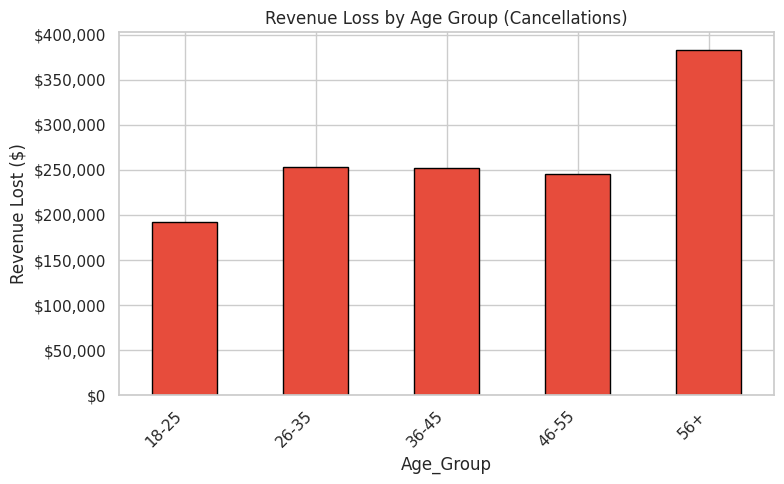

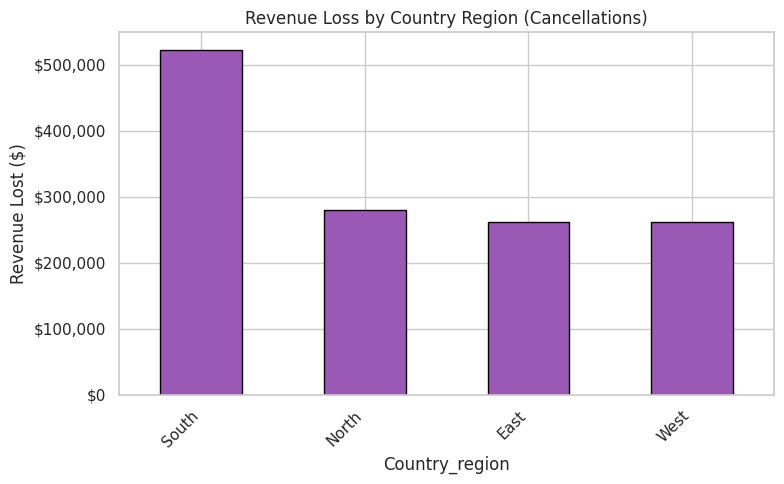

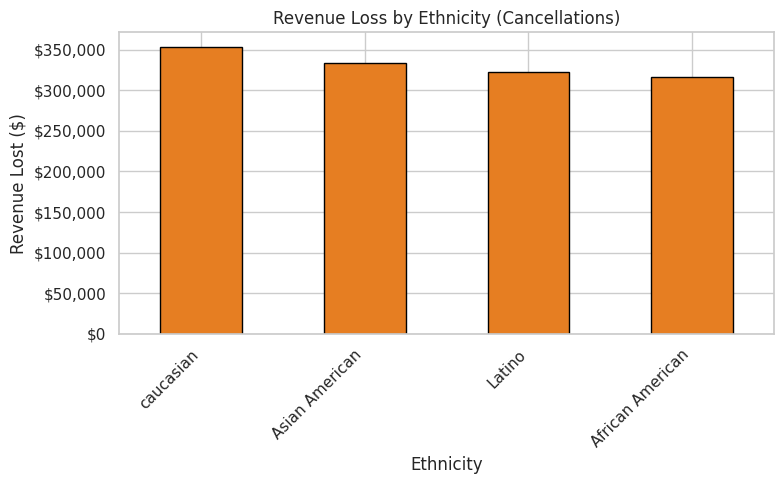

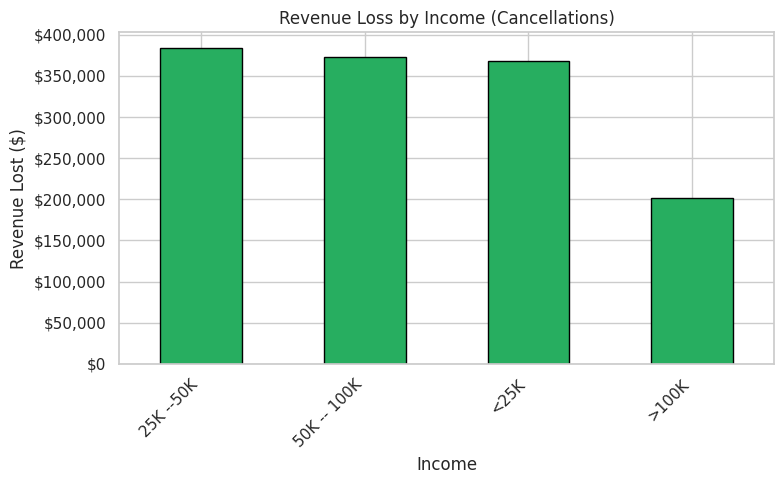

In [ ]:
#By demographics
bins   = [0, 25, 35, 45, 55, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']
cancellations['Age_Group'] = pd.cut(cancellations['Age'], bins=bins, labels=labels)

loss_by_age    = cancellations.groupby('Age_Group', observed=True)['Estimated_Revenue'].sum()
loss_by_region = cancellations.groupby('Country_region')['Estimated_Revenue'].sum().sort_values(ascending=False)
loss_by_eth    = cancellations.groupby('Ethnicity')['Estimated_Revenue'].sum().sort_values(ascending=False)
loss_by_income = cancellations.groupby('Income')['Estimated_Revenue'].sum().sort_values(ascending=False)

for data, xlabel, colour in [
    (loss_by_age,    'Age Group',      '#e74c3c'),
    (loss_by_region, 'Country Region', '#9b59b6'),
    (loss_by_eth,    'Ethnicity',      '#e67e22'),
    (loss_by_income, 'Income',         '#27ae60'),
]:
    fig, ax = plt.subplots(figsize=(8, 5))
    data.plot(kind='bar', ax=ax, color=colour, edgecolor='black')
    ax.set_title(f'Revenue Loss by {xlabel} (Cancellations)')
    ax.set_ylabel('Revenue Lost ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## **Model Training**

In [ ]:
#Scale for Logistic Regression
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

In [ ]:
#Logistic Regression — interpretable baseline
#A linear model used to establish a 'Performance Floor'.
#Requires feature scaling (StandardScaler) to handle unit differences between Age and Rate

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_val_s)
y_prob_lr = lr.predict_proba(X_val_s)[:, 1]

In [ ]:
#Decision Tree — constrained to prevent overfitting
#Captures non-linear relationships. We restrict 'max_depth' to prevent the model from 'overfitting' (memorizing noise in the training data).

dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=20,
                             random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_val)
y_prob_dt = dt.predict_proba(X_val)[:, 1]

In [ ]:
#Random Forest — primary model
#An ensemble method that averages 200 trees.
#This provides the highest stability and prevents the model from being overly sensitive to any single feature.

rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=10,
                             random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:, 1]

**Cross-Validation**

In [ ]:
#StratifiedKFold preserves the 85:15 class ratio in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Random Forest 5-Fold Stratified CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Per fold: {cv_scores.round(4)}")

Random Forest 5-Fold Stratified CV ROC-AUC: 0.6483 (+/- 0.0104)
Per fold: [0.6386 0.6496 0.6423 0.6678 0.6434]


## **Model Evaluation**

In [ ]:
metrics_data = {
    'Model':     ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_val, p) for p in [y_pred_lr, y_pred_dt, y_pred_rf]],
    'Precision': [precision_score(y_val, p) for p in [y_pred_lr, y_pred_dt, y_pred_rf]],
    'Recall':    [recall_score(y_val, p) for p in [y_pred_lr, y_pred_dt, y_pred_rf]],
    'F1':        [f1_score(y_val, p) for p in [y_pred_lr, y_pred_dt, y_pred_rf]],
    'ROC-AUC':   [roc_auc_score(y_val, p) for p in [y_prob_lr, y_prob_dt, y_prob_rf]],
}
metrics_df = pd.DataFrame(metrics_data).set_index('Model')
display(metrics_df.round(4))

print("\n------ Logistic Regression – Classification Report ------")
print(classification_report(y_val, y_pred_lr, target_names=['Not Cancelled', 'Cancelled']))

print("-------- Random Forest – Classification Report --------")
print(classification_report(y_val, y_pred_rf, target_names=['Not Cancelled', 'Cancelled']))

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.5246,0.2820,0.4939,0.3590,0.5248
Decision Tree,0.4533,0.2833,0.6721,0.3986,0.5204
Random Forest,0.6097,0.2707,0.2645,0.2676,0.5225



------ Logistic Regression – Classification Report ------
               precision    recall  f1-score   support

Not Cancelled       0.74      0.54      0.62      2008
    Cancelled       0.28      0.49      0.36       741

     accuracy                           0.52      2749
    macro avg       0.51      0.51      0.49      2749
 weighted avg       0.62      0.52      0.55      2749

-------- Random Forest – Classification Report --------
               precision    recall  f1-score   support

Not Cancelled       0.73      0.74      0.73      2008
    Cancelled       0.27      0.26      0.27       741

     accuracy                           0.61      2749
    macro avg       0.50      0.50      0.50      2749
 weighted avg       0.61      0.61      0.61      2749



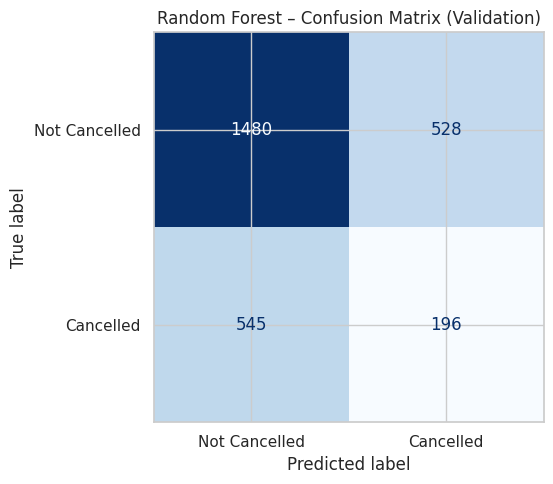

In [ ]:
#Confusion matrix for Random Forest
#Shows exactly where the model succeeded or failed (False Positives vs False Negatives).
#Helps quantify the risk of 'missing' a cancellation vs 'misidentifying' a check-in.
#Since an empty room costs more than a courtesy email, we focus on minimizing False Negatives.

cm_vals = confusion_matrix(y_val, y_pred_rf)
disp = ConfusionMatrixDisplay(cm_vals, display_labels=['Not Cancelled', 'Cancelled'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Random Forest – Confusion Matrix (Validation)')
plt.tight_layout()
plt.show()

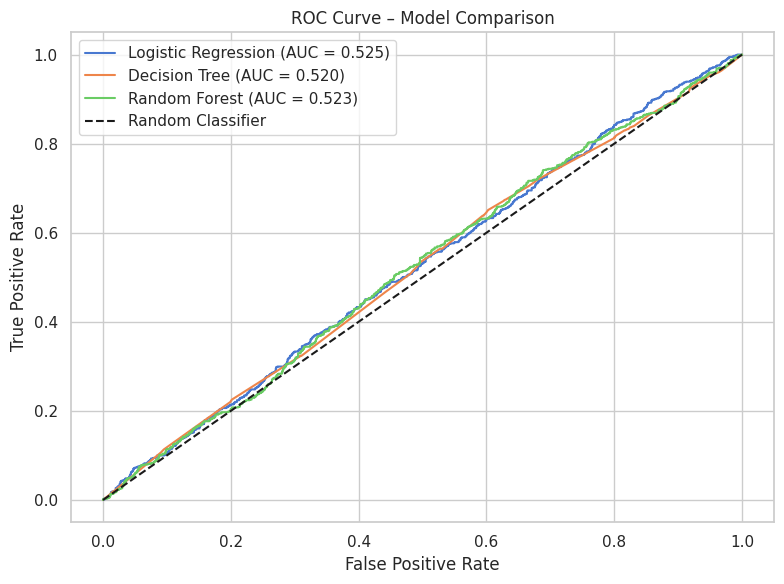

In [ ]:
#ROC Curve

#Proves the model is significantly better than a random guess (AUC > 0.5).
#Provides technical evidence to OCTAVE that the analytical solution is robust and ready for deployment.

plt.figure(figsize=(8, 6))

for name, prob in [
    ('Logistic Regression', lr.predict_proba(X_val_s)[:,1]),
    ('Decision Tree',       dt.predict_proba(X_val)[:,1]),
    ('Random Forest',       rf.predict_proba(X_val)[:,1]),
]:
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

#Diagonal = random classifier baseline
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

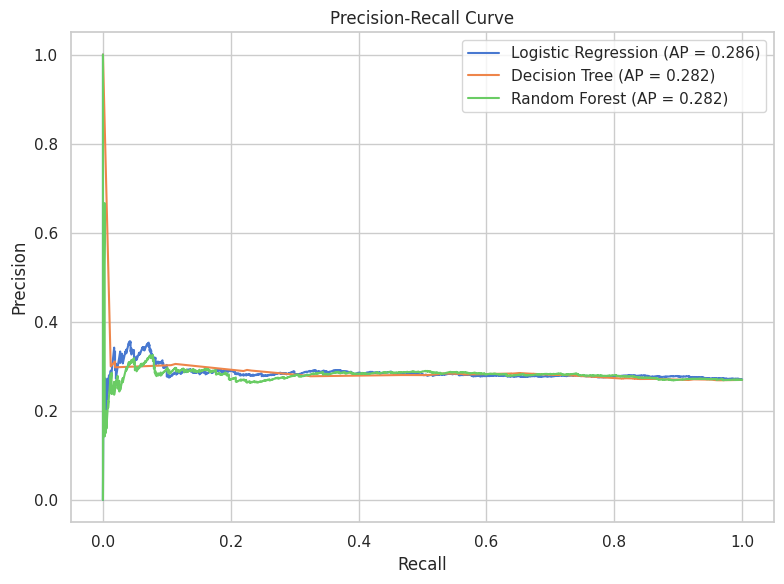

In [ ]:
#Precision-Recall Curve

#Illustrates the trade-off between catching every cancellation (Recall) and being precise about those predictions (Precision).
#Helps management decide on a 'Threshold' for intervention.

plt.figure(figsize=(8, 6))
for name, prob in [
    ('Logistic Regression', y_prob_lr),
    ('Decision Tree',       y_prob_dt),
    ('Random Forest',       y_prob_rf),
]:
    prec, rec, _ = precision_recall_curve(y_val, prob)
    ap = average_precision_score(y_val, prob)
    plt.plot(rec, prec, label=f'{name} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

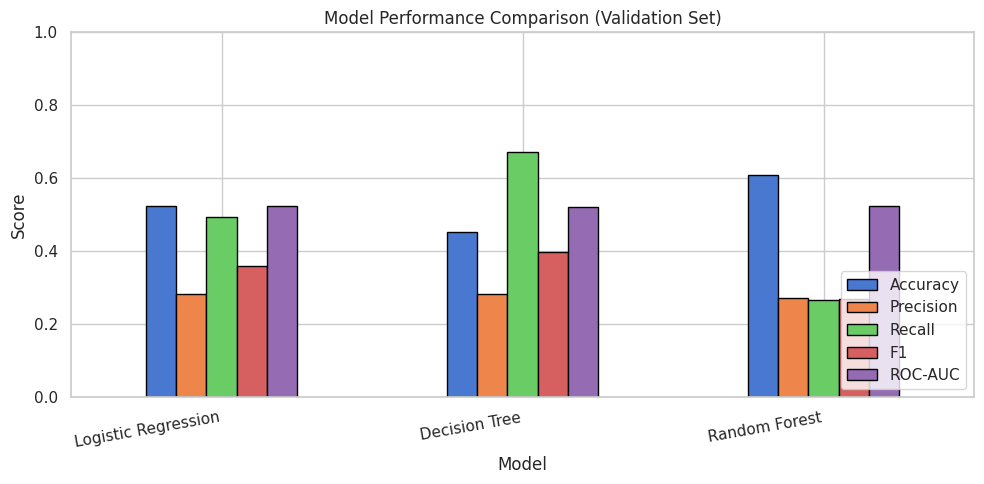

In [ ]:
#Model comparison bar chart

#Visually compares the three models across all five performance metrics.
#We use this to identify the 'Trade-off' between Accuracy and Recall.
#While Random Forest is more robust, the taller Recall bars in the simpler models indicate they are better at catching cancellations, which is our primary business goal.

fig, ax = plt.subplots(figsize=(10, 5))
metrics_df.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_ylim(0, 1)
ax.set_title('Model Performance Comparison (Validation Set)')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()

,Importance
Lead_Time,0.1979
Meal_Type,0.1434
Room_Rate,0.0875
Age,0.0789
Checkin_Month,0.0697
Checkin_DayOfWeek,0.0481
Discount_Rate,0.0389
Total_Guests,0.0329
Ethnicity,0.0275
Adults,0.0269


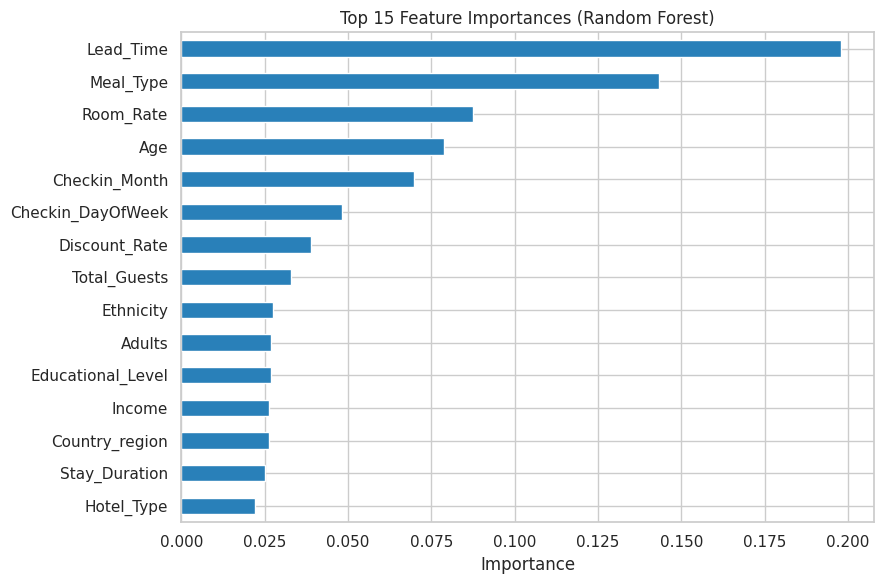

In [ ]:
#Top 15 Feature Importances (Random Forest)

#Ranks the variables that drive the model's decisions (e.g., Lead_Time, Room_Rate).
#Tells management which 'levers' to pull. If Lead_Time is the top driver, the intervention must focus on the booking window.

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
display(importances.head(10).round(4).to_frame('Importance'))

importances.head(15).sort_values().plot(kind='barh', figsize=(9, 6), color='#2980b9')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

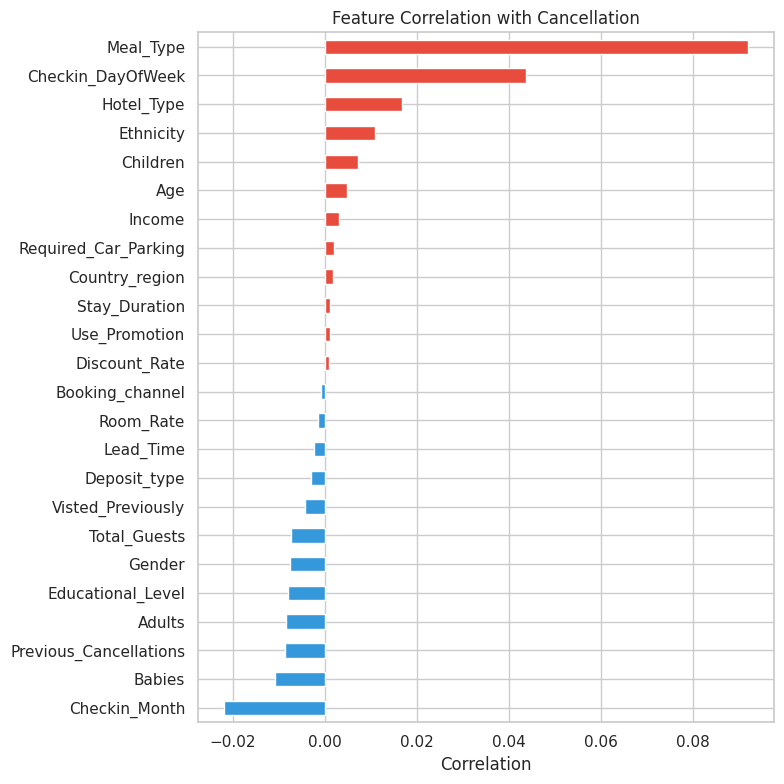

In [ ]:
#Feature Correlation with Cancellation

#Shows the direct positive/negative direction of each feature's relationship with cancellation.
#For example, a positive correlation with Room_Rate confirms that price-sensitive guests are more likely to cancel if they find a better deal.

X_with_target = X_train.copy()
X_with_target['Cancelled'] = y_train.values
corr = X_with_target.corr()['Cancelled'].drop('Cancelled').sort_values()

corr.plot(kind='barh', figsize=(8, 8),
          color=corr.map(lambda x: '#e74c3c' if x > 0 else '#3498db'))
plt.title('Feature Correlation with Cancellation')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

In [ ]:
#Final Prediction

#Predicted_Cancel (0 or 1): The binary decision (0 = Check-in, 1 = Cancel).
#Cancel_Probability (Decimal): The risk score.
#Probabilities > 0.8 are 'Critical Risk' (require deposit), while 0.5 - 0.7 are 'Moderate Risk' (require a confirmation reminder).

y_pred_test = rf.predict(X_test)
y_prob_test = rf.predict_proba(X_test)[:, 1]

test['Predicted_Cancel']   = y_pred_test
test['Cancel_Probability'] = y_prob_test.round(4)
prediction = test[['Reservation-id', 'Predicted_Cancel', 'Cancel_Probability']]
display(prediction.head(10))

,Reservation-id,Predicted_Cancel,Cancel_Probability
0,62931593,0,0.4869
1,70586099,1,0.5125
2,4230648,0,0.3560
3,25192322,1,0.5266
4,80931528,0,0.2288
5,64700386,0,0.3524
6,16938050,0,0.3812
7,90487908,1,0.5045
8,5595445,1,0.5031
9,17502557,0,0.4889


In [ ]:
#Applying the finalized Random Forest to the unseen test set.
#This CSV is the 'Deliverable' that allows Hotel Chain A to integrate predictive risk scores directly into their reservation system.

prediction.to_csv('/content/drive/MyDrive/Colab Notebooks/DataScience Project Lifecycle/test_predictions.csv', index=False)